### Exploring h5_feature_slice.h5

This file is an hdf5 dataset containing Visium HD spatial gene expression data stored in a manner to support easy and efficient fetching of 2μm resolution "image" slices for a single gene or multiple genes and bin it to arbitrary scales or plot it against the microscope tissue image.

In [3]:
# Open h5file
filepath = "../spaceranger/hd_feature_slice.h5"

h5_file = h5.File(filepath, "r")

In [5]:
# Check groups of h5 file
print("GROUPS")
for key in h5_file.keys():
    print(key)

print("\nATTRIBUTES")
# See all attributes of h5 file
for key in h5_file.attrs.keys():
    print(key, h5_file.attrs[key], sep=": ")

print("\nMETADATA")
# See all keys of metadata_json
metadata_json = json.loads(h5_file.attrs["metadata_json"])
for key in metadata_json.keys():
    print(key, metadata_json[key], sep=": ")

GROUPS
cell_annotations
feature_slices
features
images
masks
umis

ATTRIBUTES
filetype: feature_slice
metadata_json: {"sample_id":"Visium HD sample","sample_desc":null,"nrows":3350,"ncols":3350,"slide_name":"visium_hd_rc1","spot_pitch":2.0,"hd_layout_json":"{\"slide_uid\":\"H1-B3M463H\",\"file_format\":\"1.0\",\"aligner_version\":\"1.0\",\"input_hash\":\"ca1aacfc6fb52cd129d488a9c69bb189\",\"slide_design\":\"visium_hd_rc1\",\"transform\":[0.9999069528225232,0.0024328712843335993,26.165041259752726,-0.002360286586443559,0.9999890628902918,24.952688031347748,-1.1672582216275636e-8,1.4869983952786936e-8,1.0]}","transform_matrices":{"spot_colrow_to_microscope_colrow":[7.301875960616263,0.03825190242707941,3068.9633812586767,0.024343508924449593,-7.296510572665652,27911.13495175804,-2.4590547032786325e-7,3.4858712189871393e-7,1.0000011341068546],"microscope_colrow_to_spot_colrow":[0.1369339766494077,0.000696869134157217,-439.6952697729204,0.0005848834498534747,-0.13686632926671466,3818.29527

#### Cell annotations

This only has annotations(?) for the 48 micrometer binning.

In [59]:
print("\nCELL_ANNOTATIONS")
h5_file.visititems(lambda name, obj: print(name, obj) if "cell_annotations" in name else None)


CELL_ANNOTATIONS
cell_annotations <HDF5 group "/cell_annotations" (1 members)>
cell_annotations/square_048um <HDF5 group "/cell_annotations/square_048um" (2 members)>
cell_annotations/square_048um/cell_type_idx <HDF5 dataset "cell_type_idx": shape (46,), type "|S35">
cell_annotations/square_048um/matrix <HDF5 group "/cell_annotations/square_048um/matrix" (3 members)>
cell_annotations/square_048um/matrix/col <HDF5 dataset "col": shape (15054,), type "<i8">
cell_annotations/square_048um/matrix/data <HDF5 dataset "data": shape (15054,), type "<i8">
cell_annotations/square_048um/matrix/row <HDF5 dataset "row": shape (15054,), type "<i8">


In [173]:
cell_annotations = h5_file["cell_annotations"]

print(cell_annotations["square_048um"]["cell_type_idx"][:5])

print(cell_annotations["square_048um"]["matrix"]["row"][:5])
print(cell_annotations["square_048um"]["matrix"]["col"][:5])
print(cell_annotations["square_048um"]["matrix"]["data"][:5])


[b'out-of-tissue' b'B cell' b'abnormal cell' b'absorptive cell'
 b'alveolar macrophage']
[0 0 0 0 0]
[ 2 11 12 13 14]
[ 7 19 41 19 28]


### Features

This Group contains Datasets related to the feature (gene) names and ids in the reference transcriptome. It is identical to the “features” group stored in the HDF5 raw/filtered feature-barcode matrix output from the pipeline.

In [ ]:
print("\nFEATURES")
h5_file.visititems(lambda name, obj: print(name, obj) if "features" in name else None)


FEATURES
features <HDF5 group "/features" (6 members)>
features/_all_tag_keys <HDF5 dataset "_all_tag_keys": shape (1,), type "|S256">
features/feature_type <HDF5 dataset "feature_type": shape (37082,), type "|S256">
features/genome <HDF5 dataset "genome": shape (37082,), type "|S256">
features/id <HDF5 dataset "id": shape (37082,), type "|S256">
features/name <HDF5 dataset "name": shape (37082,), type "|S256">
features/target_sets <HDF5 group "/features/target_sets" (1 members)>
features/target_sets/Visium Human Transcriptome Probe Set v2.0 <HDF5 dataset "Visium Human Transcriptome Probe Set v2.0": shape (18085,), type "<u4">


In [174]:
features = h5_file["features"]

features["_all_tag_keys"][:] # array([b'genome'], dtype='|S256')
features["feature_type"][:] # Just says "Gene Expression"
features["genome"][:] # "GRCh38"
features["id"][:] # array([b'ENSG00000243485', b'ENSG00000237613', ...])
features["name"][:] # array([b'MIR1302-2HG', b'FAM138A', b'OR4F5', ...], dtype='|S256')

# Target sets
features["target_sets"].keys() # <KeysViewHDF5 ['Visium Human Transcriptome Probe Set v2.0']>
features["target_sets"]['Visium Human Transcriptome Probe Set v2.0'].shape # (18085,)


(18085,)

### Feature slices

This Group contains a Group for the index of each feature (gene) listed in hd_feature_slice.h5/features/{id}, where {id} is the index of the feature in the/features group. Only features that have at least one total UMI are stored here. That is, if a specific
feature is missing, that feature had no UMIs observed in this sample.

In [11]:
# Each feature slice is a group with row, col, data
h5_file.visititems(lambda name, obj: print(name, obj) if "feature_slices" in name else None)

feature_slices <HDF5 group "/feature_slices" (18972 members)>
feature_slices/1000 <HDF5 group "/feature_slices/1000" (3 members)>
feature_slices/1000/col <HDF5 dataset "col": shape (13212,), type "<u4">
feature_slices/1000/data <HDF5 dataset "data": shape (13212,), type "<u4">
feature_slices/1000/row <HDF5 dataset "row": shape (13212,), type "<u4">
feature_slices/10002 <HDF5 group "/feature_slices/10002" (3 members)>
feature_slices/10002/col <HDF5 dataset "col": shape (1630,), type "<u4">
feature_slices/10002/data <HDF5 dataset "data": shape (1630,), type "<u4">
feature_slices/10002/row <HDF5 dataset "row": shape (1630,), type "<u4">
feature_slices/10003 <HDF5 group "/feature_slices/10003" (3 members)>
feature_slices/10003/col <HDF5 dataset "col": shape (6134,), type "<u4">
feature_slices/10003/data <HDF5 dataset "data": shape (6134,), type "<u4">
feature_slices/10003/row <HDF5 dataset "row": shape (6134,), type "<u4">
feature_slices/10004 <HDF5 group "/feature_slices/10004" (3 members

Check with genes are missing -> do they add up?

In [187]:
# Convert KeysViewHDF5 to list
feature_slices = list(h5_file["feature_slices"].keys())

# Get missing indices between 0 to length of genes (37082)
missing_indices = list(set(range(features["id"].shape[0])) - set([int(i) for i in feature_slices]))
print("There are {} missing genes and {} profiled genes.".format(len(missing_indices), len(feature_slices)))

# Check if the length of missing indices and feature slices is equal to the length of genes
len(missing_indices) + len(feature_slices) == len(h5_file["features"]["id"])

There are 18110 missing genes and 18972 profiled genes.


True

<Axes: >

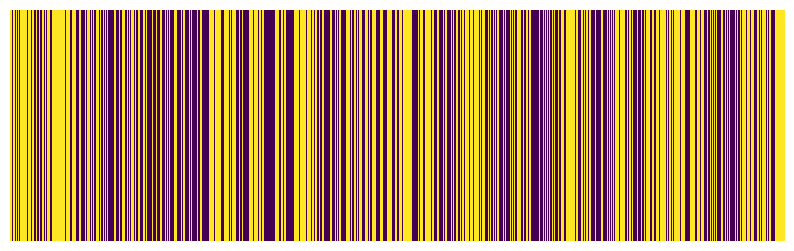

In [181]:
# Draw a heatmap indicating presence/absence of each gene across the whole tissue
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a dataframe with 37082 columns and 1 row, with the values of the columns pertaining to absence or presence of the feature
feature_presence = np.ones(37082)
feature_presence[missing_indices] = 0
df = pd.DataFrame(data=np.array(feature_presence, ndmin=2))

# Draw heatmap
# Yellow = present, purple = absent
plt.figure(figsize=(10, 3))
sns.heatmap(df, cmap="viridis", cbar=False,
            xticklabels=False, yticklabels=False)


### UMIs

This Group contains the total UMI spatial matrix at 2 micrometer.

In [116]:
# Total UMIs in each spot (2um size)
h5_file.visititems(lambda name, obj: print(name, obj) if "umis" in name else None)

umis <HDF5 group "/umis" (1 members)>
umis/total <HDF5 group "/umis/total" (3 members)>
umis/total/col <HDF5 dataset "col": shape (9580698,), type "<u4">
umis/total/data <HDF5 dataset "data": shape (9580698,), type "<u4">
umis/total/row <HDF5 dataset "row": shape (9580698,), type "<u4">


## Binning

Below is a modification of a sample binning code provided by 10x.

In [188]:
import h5py as h5
import numpy as np
import json
from typing import Union
ROW_DATASET_NAME = "row"
COL_DATASET_NAME = "col"
DATA_DATASET_NAME = "data"
METADATA_JSON_ATTR_NAME = "metadata_json"
UMIS_GROUP_NAME = "umis"
TOTAL_UMIS_GROUP_NAME = "total"

class CooMatrix:
    def __init__(self, row: list[int], col: list[int], data: list[Union[int, float]]):
        self.row = row
        self.col = col
        self.data = data

    # Shape
    @property
    def shape(self):
        return (len(self.row), len(self.col))

    @classmethod
    def from_hdf5(cls, group):
        return cls(
            row=group[ROW_DATASET_NAME][:],
            col=group[COL_DATASET_NAME][:],
            data=group[DATA_DATASET_NAME][:],
        )
    
    def to_ndarray(self, nrows, ncols, binning_scale = 1):
        """Convert the COO matrix representation to a dense ndarray at the specified binning scale."""
        ncols_binned = int(np.ceil(ncols / binning_scale))
        nrows_binned = int(np.ceil(nrows / binning_scale))
        result = np.zeros((nrows_binned, ncols_binned), dtype="int32")
    
        for row, col, data in zip(self.row, self.col, self.data):
            result[row // binning_scale, col // binning_scale] += data

        return result
    

The following code bins UMIs **of all genes** together at 8 micron.

In [155]:
metadata = json.loads(h5_file.attrs[METADATA_JSON_ATTR_NAME])
umis_8um = CooMatrix.from_hdf5(h5_file[UMIS_GROUP_NAME][TOTAL_UMIS_GROUP_NAME]).to_ndarray(
    nrows=metadata["nrows"], ncols=metadata["ncols"], binning_scale=4)

In [190]:
print(umis_8um.shape)
umis_8um

(838, 838)


array([[49, 33, 31, ..., 25, 36, 13],
       [32, 34, 26, ..., 27, 32,  7],
       [31, 30, 29, ..., 21, 22,  8],
       ...,
       [ 1,  1,  0, ...,  1,  0,  1],
       [ 1,  0,  2, ...,  0,  1,  0],
       [ 0,  0,  1, ...,  0,  0,  0]], dtype=int32)

In [227]:
# Get feature names of all genes whose index is in the feature slices
feature_names = features["name"][np.array(sorted([int(i) for i in h5_file["feature_slices"].keys()]))]
print(feature_names)

[b'OR4F5' b'SAMD11' b'NOC2L' ... b'DEPRECATED_ENSG00000283967'
 b'DEPRECATED_ENSG00000284873' b'DEPRECATED_ENSG00000285687']


In [240]:
# Binning a specific gene at 8 micron
# FAM138A, NOC2L
gene_name = "NOC2L"
binning_scale = 4

# Assert that gene_name is in feature_names
assert gene_name.encode('utf-8') in feature_names, f"{gene_name} is not captured in this dataset."

gene_idx = np.where(features["name"][:] == gene_name.encode('utf-8'))[0][0]

gene_coo = CooMatrix.from_hdf5(h5_file["feature_slices"][str(gene_idx)])
gene_binned = gene_coo.to_ndarray(
    nrows=metadata["nrows"], ncols=metadata["ncols"], binning_scale=binning_scale)


In [241]:
gene_binned.shape

(838, 838)

In [164]:
# Close h5 file
h5_file.close()

(838, 838)